# Chapter 6, Example 1: Mean-field variational inference

This notebook studies the simplest variational restriction: replace a structured Gibbs distribution by a product distribution.  The example reuses the four-spin binary cycle introduced in Chapter 2.

For spins $x_i\in\{-1,+1\}$, define

$$
p_\beta(\boldsymbol{x})
=\frac{1}{Z_\beta}
\exp\left(
\beta\sum_{(i,j)\in\mathcal E}J_{ij}x_ix_j
+\beta\sum_i h_i x_i
\right).
$$

The exact log-partition function has the variational representation

$$
\log Z_\beta
=\max_q\left\{
\beta\,\mathbb E_q\left[\sum_{(i,j)}J_{ij}x_ix_j+\sum_i h_i x_i\right]
+H(q)
\right\}.
$$

Mean field restricts $q$ to the product family $q(\boldsymbol{x})=\prod_i q_i(x_i)$.  Writing $m_i=\mathbb E_q[x_i]$, the restricted objective is

$$
\Phi_{\mathrm{MF}}(\boldsymbol m)
=
\beta\sum_{(i,j)}J_{ij}m_im_j
+\beta\sum_i h_i m_i
+\sum_i H_{\mathrm{bin}}(m_i).
$$

Because the product family is not convex, the optimization can have multiple local optima even though each coordinate update is elementary.

In [1]:
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy.optimize import minimize

CWD = Path.cwd()
if CWD.name == "ch06":
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks" / "ch06").exists():
    NOTEBOOK_DIR = CWD / "notebooks" / "ch06"
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(577)

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 19,
})

NODE_COLOR = "#30343b"
NODE_TEXT_COLOR = "white"


def save_figure(fig, stem):
    for suffix, kwargs in [("pdf", {}), ("png", {"dpi": 240})]:
        path = FIG_DIR / f"{stem}.{suffix}"
        fig.savefig(path, bbox_inches="tight", **kwargs)
        print(f"Saved: {path}")


def entropy(probabilities):
    p = np.asarray(probabilities, dtype=float)
    mask = p > 0
    return -np.sum(p[mask] * np.log(p[mask]))


def binary_entropy_from_magnetization(m):
    m = np.asarray(m, dtype=float)
    q = np.clip((1.0 + m) / 2.0, 1e-15, 1.0 - 1e-15)
    return -(q * np.log(q) + (1.0 - q) * np.log(1.0 - q))

## Exact enumeration and mean-field coordinate updates

In [2]:
N = 4
EDGES = [(0, 1), (1, 2), (2, 3), (3, 0)]
COUPLINGS = {edge: 0.72 for edge in EDGES}
FIELDS = np.array([0.12, -0.04, 0.08, 0.00])
STATES = np.array(list(product([-1, 1], repeat=N)), dtype=int)


def exact_ising(beta, couplings=COUPLINGS, fields=FIELDS):
    sufficient = np.array([
        sum(couplings[e] * state[e[0]] * state[e[1]] for e in EDGES)
        + np.dot(fields, state)
        for state in STATES
    ])
    log_weights = beta * sufficient
    shift = log_weights.max()
    weights = np.exp(log_weights - shift)
    probabilities = weights / weights.sum()
    log_z = shift + np.log(weights.sum())
    magnetizations = probabilities @ STATES
    return probabilities, log_z, magnetizations


def mean_field_objective(m, beta, couplings=COUPLINGS, fields=FIELDS):
    interaction = sum(couplings[e] * m[e[0]] * m[e[1]] for e in EDGES)
    return beta * (interaction + np.dot(fields, m)) + binary_entropy_from_magnetization(m).sum()


def coordinate_mean_field(beta, initial, damping=0.55, max_iterations=5000, tolerance=1e-12):
    m = np.asarray(initial, dtype=float).copy()
    history = [m.copy()]
    objective_history = [mean_field_objective(m, beta)]
    for _ in range(max_iterations):
        previous = m.copy()
        for i in range(N):
            effective_field = FIELDS[i]
            for u, v in EDGES:
                if u == i:
                    effective_field += COUPLINGS[(u, v)] * m[v]
                elif v == i:
                    effective_field += COUPLINGS[(u, v)] * m[u]
            target = np.tanh(beta * effective_field)
            m[i] = (1.0 - damping) * m[i] + damping * target
        history.append(m.copy())
        objective_history.append(mean_field_objective(m, beta))
        if np.max(np.abs(m - previous)) < tolerance:
            break
    return m, np.asarray(history), np.asarray(objective_history)


def best_mean_field_solution(beta):
    starts = [
        np.zeros(N),
        0.9 * np.ones(N),
        -0.9 * np.ones(N),
        np.array([0.8, -0.8, 0.8, -0.8]),
        RNG.uniform(-0.9, 0.9, N),
    ]
    solutions = [coordinate_mean_field(beta, start) for start in starts]
    return max(solutions, key=lambda item: mean_field_objective(item[0], beta)), solutions

## The model and the emergence of a nonconvex landscape

Saved: figs/ch06_01_model_and_landscape.pdf


Saved: figs/ch06_01_model_and_landscape.png


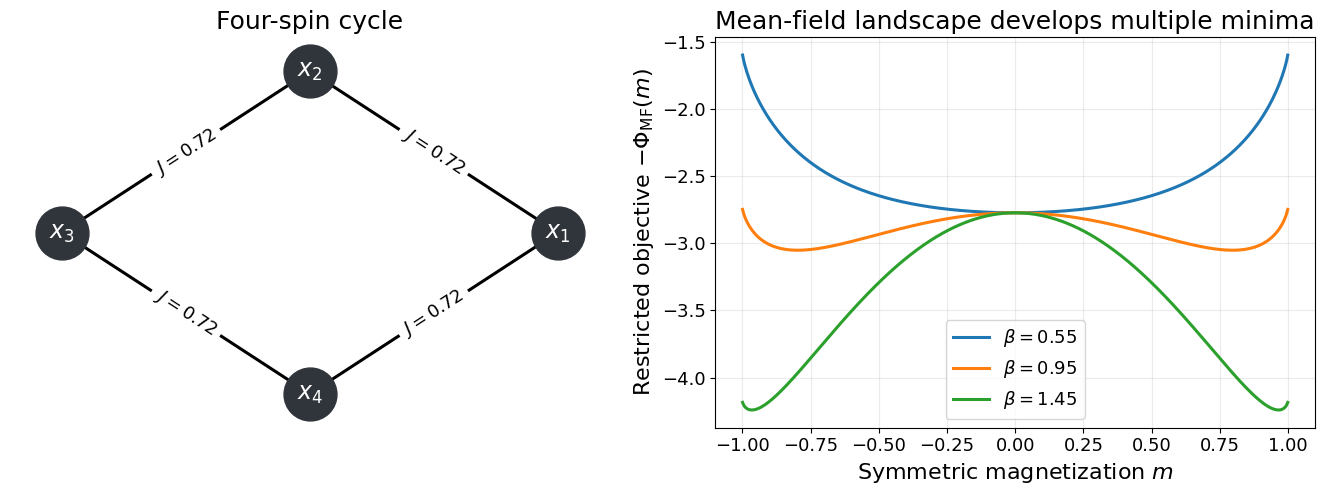

In [3]:
G = nx.Graph()
G.add_nodes_from(range(N))
G.add_edges_from(EDGES)
pos = nx.circular_layout(G)

beta_values_for_landscape = [0.55, 0.95, 1.45]
m_grid = np.linspace(-0.999, 0.999, 500)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))
nx.draw_networkx_nodes(G, pos, node_size=1450, node_color=NODE_COLOR, ax=axes[0])
nx.draw_networkx_labels(
    G, pos, labels={i: rf"$x_{i+1}$" for i in range(N)},
    font_size=17, font_color=NODE_TEXT_COLOR, ax=axes[0]
)
nx.draw_networkx_edges(G, pos, width=2.2, ax=axes[0])
nx.draw_networkx_edge_labels(
    G, pos, edge_labels={e: rf"$J={COUPLINGS[e]:.2f}$" for e in EDGES},
    font_size=13, ax=axes[0]
)
axes[0].set_title("Four-spin cycle")
axes[0].axis("off")

# Symmetric zero-field slice m_1=...=m_4=m, used only to visualize nonconvexity.
for beta in beta_values_for_landscape:
    phi = beta * len(EDGES) * COUPLINGS[EDGES[0]] * m_grid**2 \
        + N * binary_entropy_from_magnetization(m_grid)
    axes[1].plot(m_grid, -phi, linewidth=2.2, label=rf"$\beta={beta}$")
axes[1].set_xlabel(r"Symmetric magnetization $m$")
axes[1].set_ylabel(r"Restricted objective $-\Phi_{\mathrm{MF}}(m)$")
axes[1].set_title("Mean-field landscape develops multiple minima")
axes[1].grid(alpha=0.25)
axes[1].legend()
fig.tight_layout()
save_figure(fig, "ch06_01_model_and_landscape")
plt.show()

The left panel shows the graphical structure.  The right panel is a one-dimensional slice through the variational objective.  At weak coupling or high temperature, the symmetric solution is unique.  At stronger effective coupling, symmetry-related local optima appear.  This is the simplest warning that mean-field coordinate updates are guaranteed to improve the objective but are not guaranteed to find its global optimum.

## Exact versus mean-field log-partition functions and marginals

Saved: figs/ch06_01_exact_vs_mean_field.pdf


Saved: figs/ch06_01_exact_vs_mean_field.png


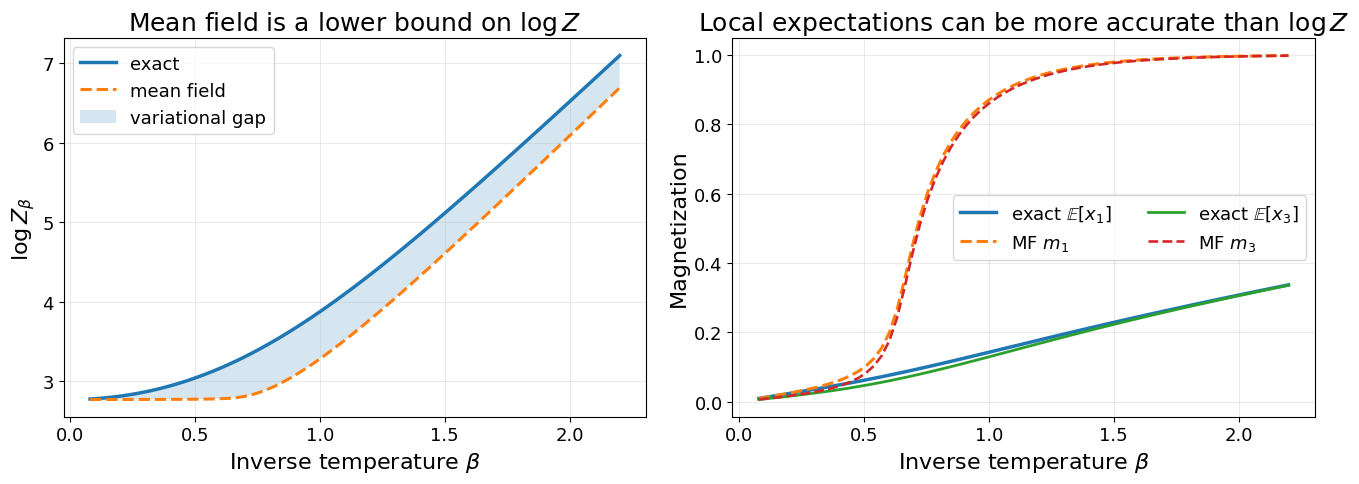

In [4]:
beta_grid = np.linspace(0.08, 2.2, 70)
exact_log_z = []
mf_log_z = []
exact_magnetization = []
mf_magnetization = []

for beta in beta_grid:
    probabilities, log_z, exact_m = exact_ising(beta)
    best, _ = best_mean_field_solution(beta)
    mf_m = best[0]
    exact_log_z.append(log_z)
    mf_log_z.append(mean_field_objective(mf_m, beta))
    exact_magnetization.append(exact_m)
    mf_magnetization.append(mf_m)

exact_log_z = np.asarray(exact_log_z)
mf_log_z = np.asarray(mf_log_z)
exact_magnetization = np.asarray(exact_magnetization)
mf_magnetization = np.asarray(mf_magnetization)

assert np.all(mf_log_z <= exact_log_z + 2e-9)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.1))
axes[0].plot(beta_grid, exact_log_z, linewidth=2.5, label="exact")
axes[0].plot(beta_grid, mf_log_z, linestyle="--", linewidth=2.2, label="mean field")
axes[0].fill_between(beta_grid, mf_log_z, exact_log_z, alpha=0.18, label="variational gap")
axes[0].set_xlabel(r"Inverse temperature $\beta$")
axes[0].set_ylabel(r"$\log Z_\beta$")
axes[0].set_title(r"Mean field is a lower bound on $\log Z$")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(beta_grid, exact_magnetization[:, 0], linewidth=2.5, label=r"exact $\mathbb{E}[x_1]$")
axes[1].plot(beta_grid, mf_magnetization[:, 0], linestyle="--", linewidth=2.2, label=r"MF $m_1$")
axes[1].plot(beta_grid, exact_magnetization[:, 2], linewidth=2.0, label=r"exact $\mathbb{E}[x_3]$")
axes[1].plot(beta_grid, mf_magnetization[:, 2], linestyle="--", linewidth=1.9, label=r"MF $m_3$")
axes[1].set_xlabel(r"Inverse temperature $\beta$")
axes[1].set_ylabel("Magnetization")
axes[1].set_title(r"Local expectations can be more accurate than $\log Z$")
axes[1].grid(alpha=0.25)
axes[1].legend(ncol=2)
fig.tight_layout()
save_figure(fig, "ch06_01_exact_vs_mean_field")
plt.show()

## Coordinate updates, initialization, and local optima

Saved: figs/ch06_01_coordinate_updates.pdf


Saved: figs/ch06_01_coordinate_updates.png


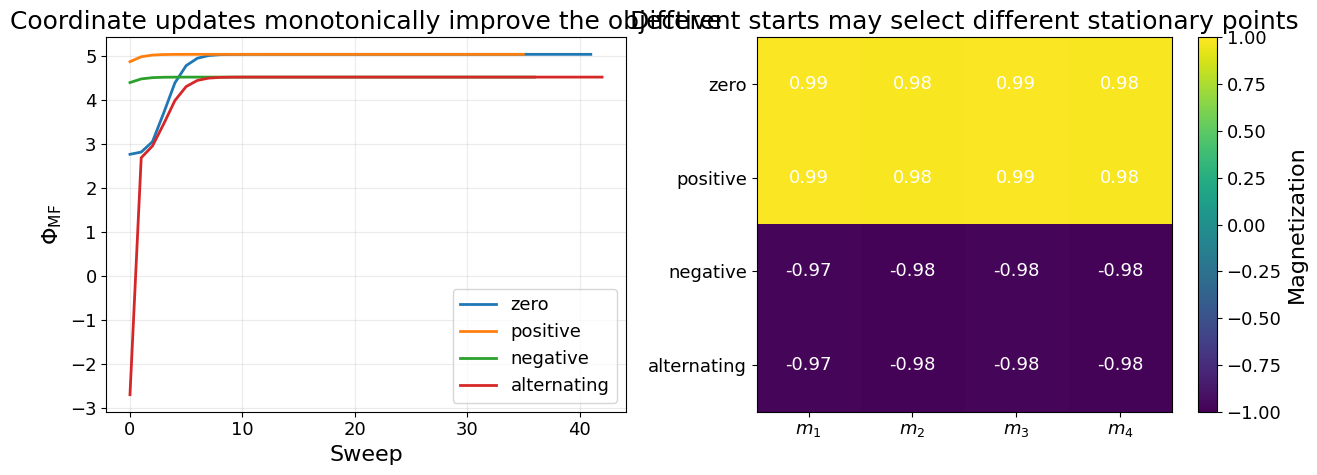

,m1,m2,m3,m4
zero,0.987329,0.979202,0.985554,0.981750
positive,0.987329,0.979202,0.985554,0.981750
negative,-0.972414,-0.983030,-0.975784,-0.980658
alternating,-0.972414,-0.983030,-0.975784,-0.980658


In [5]:
beta = 1.65
initializations = {
    "zero": np.zeros(N),
    "positive": 0.9 * np.ones(N),
    "negative": -0.9 * np.ones(N),
    "alternating": np.array([0.9, -0.9, 0.9, -0.9]),
}
results = {name: coordinate_mean_field(beta, start) for name, start in initializations.items()}

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.0))
for name, (_, history, objective_history) in results.items():
    axes[0].plot(objective_history, linewidth=2.0, label=name)
axes[0].set_xlabel("Sweep")
axes[0].set_ylabel(r"$\Phi_{\mathrm{MF}}$")
axes[0].set_title("Coordinate updates monotonically improve the objective")
axes[0].grid(alpha=0.25)
axes[0].legend()

finals = np.vstack([results[name][0] for name in initializations])
image = axes[1].imshow(finals, vmin=-1, vmax=1, aspect="auto")
axes[1].set_xticks(range(N), [rf"$m_{i+1}$" for i in range(N)])
axes[1].set_yticks(range(len(initializations)), list(initializations))
axes[1].set_title("Different starts may select different stationary points")
for i in range(finals.shape[0]):
    for j in range(finals.shape[1]):
        value = finals[i, j]
        axes[1].text(j, i, f"{value:.2f}", ha="center", va="center",
                     color="white" if abs(value) > 0.45 else "black", fontsize=13)
fig.colorbar(image, ax=axes[1], label="Magnetization")
fig.tight_layout()
save_figure(fig, "ch06_01_coordinate_updates")
plt.show()

pd.DataFrame(finals, index=initializations, columns=[f"m{i+1}" for i in range(N)])

## Exercises

1. **Basic.** Replace the cycle by the chain used in Chapter 2.  Compare the mean-field gap on the chain and cycle over the same $\beta$ range.
2. **Extension.** Add a strong positive field at one node.  Explain why the number of distinct stationary points changes.
3. **Algorithmic.** Replace sequential coordinate updates by parallel updates.  Find a regime where damping is needed.
4. **Research.** Implement a two-block structured mean-field approximation in which $(x_1,x_2)$ and $(x_3,x_4)$ are retained as dependent blocks.  Verify that its lower bound on $\log Z$ is at least as tight as the fully factorized bound.